In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import utils
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

TRANSFER_FILE = "data/erc1155_transfers.parquet"
NULL_ADDRESS = "0x0000000000000000000000000000000000000000"

# Analysis of ERC-1155 airdrops

This notebook focuses on the analysis of out-star networks, i.e., ERC-1155 transfer networks with out-degree centralization index == 1 (and in-degree centralization index != 1).

In [2]:
spam_labels = pl.read_csv("results/provided/alchemy_labels.tsv", separator="\t", has_header=False, new_columns=["address", "is_spam"])
deployers = pl.read_csv("results/provided/out_deployers.tsv", separator="\t")
df = spam_labels.join(deployers, on="address", how="left")
contract_addresses = df['address'].to_list()

tdf = pl.read_parquet(TRANSFER_FILE)
tdf = utils.filter_transfers(tdf)
tdf = tdf.explode(['token_ids', 'amounts'])
tdf = tdf.filter((pl.col('from') != NULL_ADDRESS) & (pl.col('to') != NULL_ADDRESS) & (pl.col('from') != pl.col('to')))
tmp = tdf.filter(pl.col('address').is_in(contract_addresses))
diff_df = tmp.group_by("address").agg(
    pl.col("block_number").min().alias("first_block"), 
    pl.col("block_number").max().alias("last_block")
).with_columns(activity_time=(pl.col("last_block") - pl.col("first_block")))

df = df.join(diff_df, on='address', how='left')
df 

address,is_spam,deployer,first_block,last_block,activity_time
str,bool,str,i64,i64,i64
"""0x699a884a3e41bbab0b9b68ac6d74…",true,"""0x3d8233b70f63061d4d1feb6a5404…",18065992,18073689,7697
"""0xb759b80efd95c17c3ef82fcf0b94…",true,"""0x93e87f38c00c03e6fbf7a0bbe3d8…",18070689,18585683,514994
"""0x17b56b0737e413ef8c38008ec95f…",true,"""0x9b108e827ecbd3bebd1d76d8935a…",18023390,18028977,5587
"""0xc63d4171dfa493a1566ad747cb51…",true,"""0xfdbc34d75c0137e1acdd3308db8e…",18040208,18040308,100
"""0x5d3f7690df8bc854cc37e1077189…",true,"""0x13364b061e92501efd7d92611e27…",17963443,17973907,10464
…,…,…,…,…,…
"""0x55d54ea469a1a896cdbb2b8fb0ad…",false,"""0xd9d9ed2b5ee5aa3720ad1e4a45a8…",16634711,16634717,6
"""0x0bca20cdfa83988e3dbe186e38e3…",false,"""0x72c8927160be405df618f241973f…",18312252,18312259,7
"""0xa02edee1138a3d4a521ebabe4042…",false,"""0x3654075cbee895ba8887b91f5c46…",21167727,21369143,201416


In [6]:
df['is_spam'].value_counts(normalize=True)

is_spam,proportion
bool,f64
true,0.798977
false,0.201023


In [8]:
df['activity_time'].describe()

statistic,value
str,f64
"""count""",15441.0
"""null_count""",0.0
"""mean""",91088.734667
"""std""",430325.242927
"""min""",0.0
"""25%""",0.0
"""50%""",0.0
"""75%""",58.0
"""max""",8.945714e6


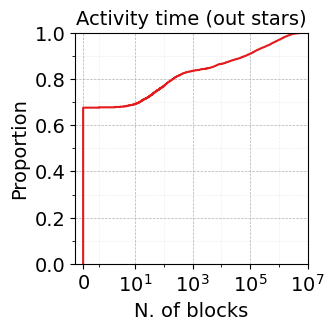

In [10]:
fig, ax = plt.subplots(figsize=(3, 3))
sns.ecdfplot(data=df, x="activity_time", stat="proportion", color='#e41a1c', ax=ax)
ax.set_title('Activity time (out stars)')
ax.set_xlabel('N. of blocks')
ax.set_xscale("symlog")
ax.set_xlim(left=-0.5)
ax.xaxis.set_ticks([0, 1e1, 1e3, 1e5, 1e7])
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
utils.set_font_size(ax, 14)
plt.savefig("figures/airdrop-activity-time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [11]:
data = df['activity_time'].value_counts()
data

activity_time,count
i64,u32
158150,1
363,2
78599,1
350479,1
217002,1
…,…
44034,1
102654,1
17387,1


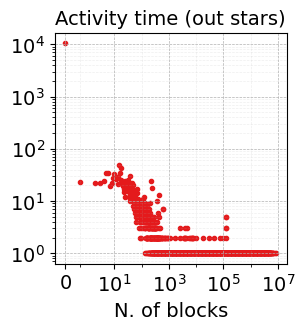

In [12]:
data = df['activity_time'].value_counts()
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(data['activity_time'], data['count'], color='#e41a1c', marker='.')
ax.set_title('Activity time (out stars)')
ax.set_xlabel('N. of blocks')
ax.set_xscale('symlog')
ax.set_yscale('log')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_ticks([0, 1e1, 1e3, 1e5, 1e7])
utils.set_font_size(ax, 14)
plt.show()

## Deployer analysis

In [13]:
x = df.group_by("deployer").agg(pl.len().alias("num_contracts")).sort("num_contracts", descending=True)
x

deployer,num_contracts
str,u32
"""0x1a199a530579440643f6fe32b8dc…",67
"""0xc1fb8bc41519377b8b94f03aea5e…",64
"""0x84747bdbe46aff87dae5817d1793…",60
"""0x978ab9513afab50ec7d65e09f425…",60
"""0x8e2f3c1d642da7aad1c5ba82c70f…",60
…,…
"""0xe5772129cd0bfaa11991b4c2e841…",1
"""0x235fea95468d13166ff6da899ecf…",1
"""0x5c3bad06362f14770bdf57d4b53a…",1


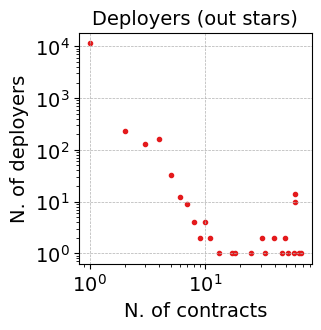

In [14]:
data = x['num_contracts'].value_counts(name="num_deployers").sort("num_deployers", descending=True)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Deployers (out stars)')
ax.set_xlabel('N. of contracts')
ax.set_ylabel('N. of deployers')
ax.scatter(data['num_contracts'], data['num_deployers'], color='#e41a1c', marker='.')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='major', linestyle='--', linewidth=0.5)
utils.set_font_size(ax, 14)
plt.savefig("figures/airdrop-deployers.pdf", format='pdf', bbox_inches='tight')
plt.show()